In [2]:
import pandas as pd



In [7]:
df =  pd.read_excel("C:\\Users\\LENOVO\\Desktop\\TOP MENTOR\\Machine Learning\\Cohort 140_Day 45 Projects-20260723T102403Z-1-001\\Cohort 140_Day 45 Projects\\Project -Flight Price Predict\\Data_Train.xlsx")

In [8]:
display(df.head())

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [9]:
y = df['Price']

In [10]:
df.shape

(10683, 11)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [12]:
df.isnull()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
10678,False,False,False,False,False,False,False,False,False,False,False
10679,False,False,False,False,False,False,False,False,False,False,False
10680,False,False,False,False,False,False,False,False,False,False,False
10681,False,False,False,False,False,False,False,False,False,False,False


In [13]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [14]:
df[df.isnull().any(axis=1)]

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
9039,Air India,6/05/2019,Delhi,Cochin,NaN,09:45,09:25 07 May,23h 40m,NaN,No info,7480


In [16]:
df.dropna(inplace=True)

In [17]:
df.dropna()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648


In [19]:
df.dropna(inplace=True)

In [20]:
df.shape

(10682, 11)

In [22]:
df["Journey_Day"] = pd.to_datetime(df.Date_of_Journey, format="%d/%m/%Y").dt.day
df["Journey_Month"] = pd.to_datetime(df.Date_of_Journey, format="%d/%m/%Y").dt.month

In [23]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,6
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,5
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1,3


In [25]:
df["Dep_Hour"] = pd.to_datetime(df["Dep_Time"], format="%H:%M").dt.hour
df["Dep_Minute"] = pd.to_datetime(df["Dep_Time"], format="%H:%M").dt.minute

In [26]:
df[["Dep_Time", "Dep_Hour", "Dep_Minute"]].head()

,Dep_Time,Dep_Hour,Dep_Minute
0,22:20,22,20
1,05:50,5,50
2,09:25,9,25
3,18:05,18,5
4,16:50,16,50


In [27]:
df["Arrival_Hour"] = pd.to_datetime(df["Arrival_Time"]).dt.hour
df["Arrival_Minute"] = pd.to_datetime(df["Arrival_Time"]).dt.minute

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_16256\2744917568.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Arrival_Hour"] = pd.to_datetime(df["Arrival_Time"]).dt.hour
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_16256\2744917568.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Arrival_Minute"] = pd.to_datetime(df["Arrival_Time"]).dt.minute


In [28]:
df[["Arrival_Time", "Arrival_Hour", "Arrival_Minute"]].head()

,Arrival_Time,Arrival_Hour,Arrival_Minute
0,01:10 22 Mar,1,10
1,13:15,13,15
2,04:25 10 Jun,4,25
3,23:30,23,30
4,21:35,21,35


In [29]:
df["Duration"].unique()

array(['2h 50m', '7h 25m', '19h', '5h 25m', '4h 45m', '2h 25m', '15h 30m',
       '21h 5m', '25h 30m', '7h 50m', '13h 15m', '2h 35m', '2h 15m',
       '12h 10m', '26h 35m', '4h 30m', '22h 35m', '23h', '20h 35m',
       '5h 10m', '15h 20m', '2h 55m', '13h 20m', '15h 10m', '5h 45m',
       '5h 55m', '13h 25m', '22h', '5h 30m', '10h 25m', '5h 15m',
       '2h 30m', '6h 15m', '11h 55m', '11h 5m', '8h 30m', '22h 5m',
       '2h 45m', '12h', '16h 5m', '19h 55m', '3h 15m', '25h 20m', '3h',
       '16h 15m', '15h 5m', '6h 30m', '25h 5m', '12h 25m', '27h 20m',
       '10h 15m', '10h 30m', '1h 30m', '1h 25m', '26h 30m', '7h 20m',
       '13h 30m', '5h', '19h 5m', '14h 50m', '2h 40m', '22h 10m',
       '9h 35m', '10h', '21h 20m', '18h 45m', '12h 20m', '18h', '9h 15m',
       '17h 30m', '16h 35m', '12h 15m', '7h 30m', '24h', '8h 55m',
       '7h 10m', '14h 30m', '30h 20m', '15h', '12h 45m', '10h 10m',
       '15h 25m', '14h 5m', '20h 15m', '23h 10m', '18h 10m', '16h',
       '2h 20m', '8h', '16h 5

In [30]:
def duration_to_minutes(duration):
    hours = 0
    minutes = 0
    
    if "h" in duration:
        hours = int(duration.split("h")[0])
    
    if "m" in duration:
        if "h" in duration:
            minutes = int(duration.split("h")[1].replace("m", "").strip())
        else:
            minutes = int(duration.replace("m", "").strip())
    
    return hours * 60 + minutes


df["Duration_Minutes"] = df["Duration"].apply(duration_to_minutes)

In [31]:
df[["Duration", "Duration_Minutes"]].head(10)

,Duration,Duration_Minutes
0,2h 50m,170
1,7h 25m,445
2,19h,1140
3,5h 25m,325
4,4h 45m,285
5,2h 25m,145
6,15h 30m,930
7,21h 5m,1265
8,25h 30m,1530
9,7h 50m,470


In [32]:
df["Total_Stops"].unique()

array(['non-stop', '2 stops', '1 stop', '3 stops', '4 stops'],
      dtype=object)

In [33]:
df["Total_Stops"] = df["Total_Stops"].map({
    "non-stop": 0,
    "1 stop": 1,
    "2 stops": 2,
    "3 stops": 3,
    "4 stops": 4
})

In [34]:
df["Total_Stops"].unique()

array([0, 2, 1, 3, 4])

In [35]:
df["Additional_Info"].unique()


array(['No info', 'In-flight meal not included',
       'No check-in baggage included', '1 Short layover', 'No Info',
       '1 Long layover', 'Change airports', 'Business class',
       'Red-eye flight', '2 Long layover'], dtype=object)

In [36]:
df["Additional_Info"].value_counts()

Additional_Info
No info                         8344
In-flight meal not included     1982
No check-in baggage included     320
1 Long layover                    19
Change airports                    7
Business class                     4
No Info                            3
1 Short layover                    1
Red-eye flight                     1
2 Long layover                     1
Name: count, dtype: int64

In [37]:
df.drop(["Additional_Info"], axis=1, inplace=True)

In [38]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Price,Journey_Day,Journey_Month,Dep_Hour,Dep_Minute,Arrival_Hour,Arrival_Minute,Duration_Minutes
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,0,3897,24,3,22,20,1,10,170
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2,7662,1,5,5,50,13,15,445
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2,13882,9,6,9,25,4,25,1140
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1,6218,12,5,18,5,23,30,325
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1,13302,1,3,16,50,21,35,285


In [39]:
df["Route"].head(10)

0                BLR → DEL
1    CCU → IXR → BBI → BLR
2    DEL → LKO → BOM → COK
3          CCU → NAG → BLR
4          BLR → NAG → DEL
5                CCU → BLR
6          BLR → BOM → DEL
7          BLR → BOM → DEL
8          BLR → BOM → DEL
9          DEL → BOM → COK
Name: Route, dtype: object

In [40]:
df.drop(["Route"], axis=1, inplace=True)

In [41]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Dep_Time,Arrival_Time,Duration,Total_Stops,Price,Journey_Day,Journey_Month,Dep_Hour,Dep_Minute,Arrival_Hour,Arrival_Minute,Duration_Minutes
0,IndiGo,24/03/2019,Banglore,New Delhi,22:20,01:10 22 Mar,2h 50m,0,3897,24,3,22,20,1,10,170
1,Air India,1/05/2019,Kolkata,Banglore,05:50,13:15,7h 25m,2,7662,1,5,5,50,13,15,445
2,Jet Airways,9/06/2019,Delhi,Cochin,09:25,04:25 10 Jun,19h,2,13882,9,6,9,25,4,25,1140
3,IndiGo,12/05/2019,Kolkata,Banglore,18:05,23:30,5h 25m,1,6218,12,5,18,5,23,30,325
4,IndiGo,01/03/2019,Banglore,New Delhi,16:50,21:35,4h 45m,1,13302,1,3,16,50,21,35,285


In [42]:
print(df["Airline"].unique())
print(df["Source"].unique())
print(df["Destination"].unique())

['IndiGo' 'Air India' 'Jet Airways' 'SpiceJet' 'Multiple carriers' 'GoAir'
 'Vistara' 'Air Asia' 'Vistara Premium economy' 'Jet Airways Business'
 'Multiple carriers Premium economy' 'Trujet']
['Banglore' 'Kolkata' 'Delhi' 'Chennai' 'Mumbai']
['New Delhi' 'Banglore' 'Cochin' 'Kolkata' 'Delhi' 'Hyderabad']


In [43]:
Airline = pd.get_dummies(df["Airline"], drop_first=True)
Source = pd.get_dummies(df["Source"], drop_first=True)
Destination = pd.get_dummies(df["Destination"], drop_first=True)

In [44]:
Airline.head()

,Air India,GoAir,IndiGo,Jet Airways,Jet Airways Business,Multiple carriers,Multiple carriers Premium economy,SpiceJet,Trujet,Vistara,Vistara Premium economy
0,False,False,True,False,False,False,False,False,False,False,False
1,True,False,False,False,False,False,False,False,False,False,False
2,False,False,False,True,False,False,False,False,False,False,False
3,False,False,True,False,False,False,False,False,False,False,False
4,False,False,True,False,False,False,False,False,False,False,False


In [45]:
Source.head()

,Chennai,Delhi,Kolkata,Mumbai
0,False,False,False,False
1,False,False,True,False
2,False,True,False,False
3,False,False,True,False
4,False,False,False,False


In [46]:
Destination.head()

,Cochin,Delhi,Hyderabad,Kolkata,New Delhi
0,False,False,False,False,True
1,False,False,False,False,False
2,True,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,True


In [47]:
df = pd.concat([df, Airline, Source, Destination], axis=1)

In [48]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Dep_Time,Arrival_Time,Duration,Total_Stops,Price,Journey_Day,...,Vistara Premium economy,Chennai,Delhi,Kolkata,Mumbai,Cochin,Delhi,Hyderabad,Kolkata,New Delhi
0,IndiGo,24/03/2019,Banglore,New Delhi,22:20,01:10 22 Mar,2h 50m,0,3897,24,...,False,False,False,False,False,False,False,False,False,True
1,Air India,1/05/2019,Kolkata,Banglore,05:50,13:15,7h 25m,2,7662,1,...,False,False,False,True,False,False,False,False,False,False
2,Jet Airways,9/06/2019,Delhi,Cochin,09:25,04:25 10 Jun,19h,2,13882,9,...,False,False,True,False,False,True,False,False,False,False
3,IndiGo,12/05/2019,Kolkata,Banglore,18:05,23:30,5h 25m,1,6218,12,...,False,False,False,True,False,False,False,False,False,False
4,IndiGo,01/03/2019,Banglore,New Delhi,16:50,21:35,4h 45m,1,13302,1,...,False,False,False,False,False,False,False,False,False,True


In [49]:
df.shape

(10682, 36)

In [50]:
df.drop([
    "Airline",
    "Date_of_Journey",
    "Source",
    "Destination",
    "Dep_Time",
    "Arrival_Time",
    "Duration"
], axis=1, inplace=True)

In [51]:
df.shape

(10682, 29)

In [52]:
X = df.drop("Price", axis=1)
y = df["Price"]

In [53]:
print(X.shape)
print(y.shape)

(10682, 28)
(10682,)


In [54]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [55]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(8545, 28)
(2137, 28)
(8545,)
(2137,)


In [56]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [57]:
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [58]:
y_pred = rf.predict(X_test)

In [59]:
print(y_pred[:10])

[16723.99        5568.51        8952.53        3675.06
 15020.00333333  9665.09397619 12900.4925      5589.9125
 14285.94666667 13851.70166667]


In [60]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

MAE: 1157.6210300813939
MSE: 3850463.0222967304
RMSE: 1962.2596724941197


In [61]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

R2 Score: 0.8214241274389948


In [62]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
7,Duration_Minutes,0.465653
1,Journey_Day,0.127988
2,Journey_Month,0.063409
12,Jet Airways Business,0.062815
11,Jet Airways,0.057899
5,Arrival_Hour,0.037433
0,Total_Stops,0.032909
3,Dep_Hour,0.030350
4,Dep_Minute,0.026491
6,Arrival_Minute,0.022125


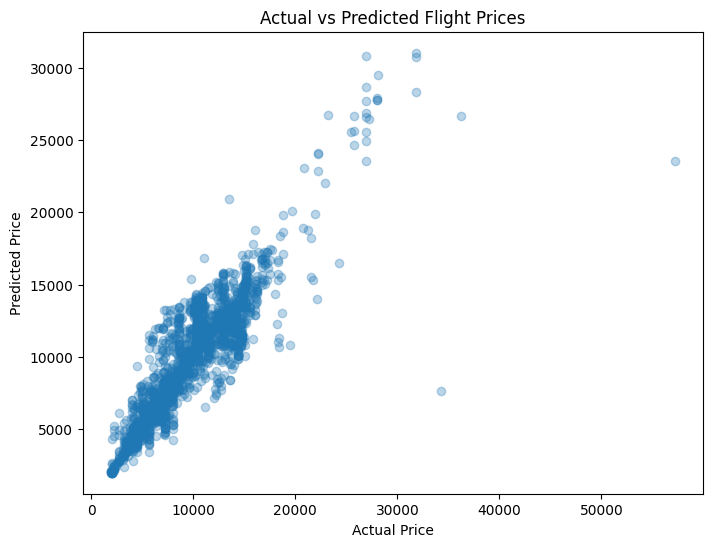

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Flight Prices")

plt.show()

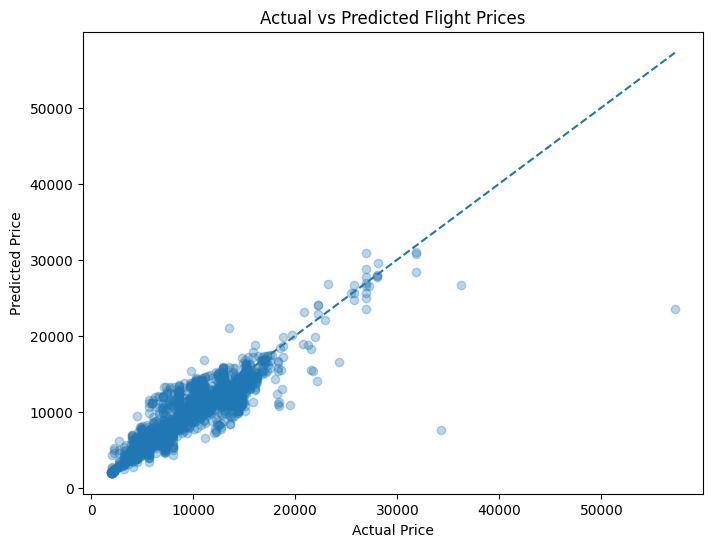

In [64]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.3)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Flight Prices")

plt.show()

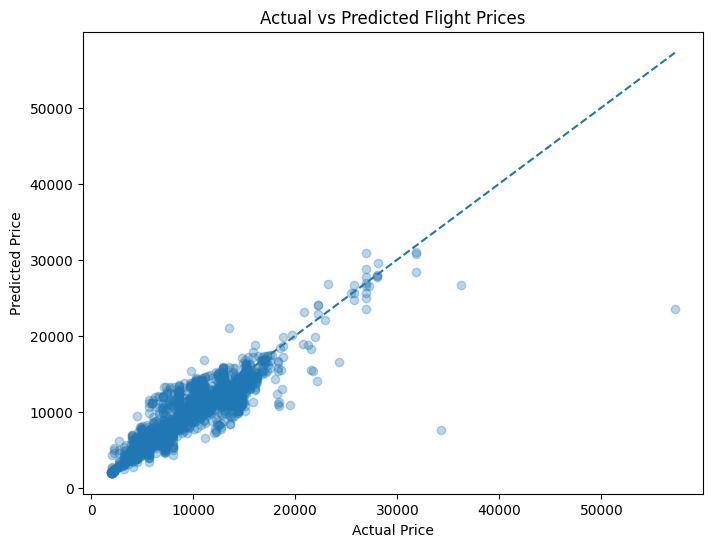

In [65]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.3)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Flight Prices")

plt.show()

In [66]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [67]:
y_pred_dt = dt.predict(X_test)

In [68]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("MAE:", mae_dt)
print("MSE:", mse_dt)
print("RMSE:", rmse_dt)
print("R2 Score:", r2_dt)

MAE: 1286.803423802839
MSE: 4759350.382463604
RMSE: 2181.593541992551
R2 Score: 0.7792719622418192


In [69]:
RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [70]:
baseline_results = {
    "Random Forest": {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    },
    "Decision Tree": {
        "MAE": mae_dt,
        "RMSE": rmse_dt,
        "R2": r2_dt
    }
}

baseline_results

{'Random Forest': {'MAE': 1157.6210300813939,
  'RMSE': np.float64(1962.2596724941197),
  'R2': 0.8214241274389948},
 'Decision Tree': {'MAE': 1286.803423802839,
  'RMSE': np.float64(2181.593541992551),
  'R2': 0.7792719622418192}}

In [78]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

rf_tuning = RandomForestRegressor(random_state=42)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    estimator=rf_tuning,
    param_grid=param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [82]:
print("Best Parameters:", grid_search.best_params_)
print("Best CV R2:", grid_search.best_score_)

Best Parameters: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best CV R2: 0.7817269533610665


In [83]:
best_rf = grid_search.best_estimator_

In [84]:
y_pred_tuned = best_rf.predict(X_test)

mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
mse_tuned = mean_squared_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mse_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

print("Tuned Random Forest")
print("MAE:", mae_tuned)
print("MSE:", mse_tuned)
print("RMSE:", rmse_tuned)
print("R2 Score:", r2_tuned)

Tuned Random Forest
MAE: 1129.8090678789872
MSE: 3966658.3341648625
RMSE: 1991.6471409777544
R2 Score: 0.8160352484693241


In [85]:
errors = y_test - y_pred

print("Mean Error:", errors.mean())
print("Median Error:", errors.median())
print("Minimum Error:", errors.min())
print("Maximum Error:", errors.max())

Mean Error: -76.75871341786689
Median Error: -36.340000000000146
Minimum Error: -7435.779999999999
Maximum Error: 33654.6


In [86]:
error_analysis = pd.DataFrame({
    "Actual_Price": y_test,
    "Predicted_Price": y_pred,
    "Error": errors
})

error_analysis["Absolute_Error"] = error_analysis["Error"].abs()

error_analysis.sort_values(
    by="Absolute_Error",
    ascending=False
).head(10)

,Actual_Price,Predicted_Price,Error,Absolute_Error
10364,57209,23554.400000,33654.600000,33654.600000
6991,34273,7617.200000,26655.800000,26655.800000
5719,36235,26634.510000,9600.490000,9600.490000
2628,19508,10834.253333,8673.746667,8673.746667
5850,22153,13976.430000,8176.570000,8176.570000
10160,24318,16476.440000,7841.560000,7841.560000
1835,18371,10686.862000,7684.138000,7684.138000
8718,13502,20937.780000,-7435.780000,7435.780000
5308,18308,11006.957500,7301.042500,7301.042500
6686,18371,11312.270333,7058.729667,7058.729667


In [88]:
worst_indices = error_analysis.sort_values(
    by="Absolute_Error",
    ascending=False
).head(10).index

df.loc[
    worst_indices,
    [
        "Airline",
        "Date_of_Journey",
        "Source",
        "Destination",
        "Route",
        "Dep_Time",
        "Arrival_Time",
        "Duration",
        "Total_Stops",
        "Additional_Info",
        "Price"
    ]
]

KeyError: "['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route', 'Dep_Time', 'Arrival_Time', 'Duration', 'Additional_Info'] not in index"

In [89]:
df.columns

Index(['Total_Stops', 'Price', 'Journey_Day', 'Journey_Month', 'Dep_Hour',
       'Dep_Minute', 'Arrival_Hour', 'Arrival_Minute', 'Duration_Minutes',
       'Air India', 'GoAir', 'IndiGo', 'Jet Airways', 'Jet Airways Business',
       'Multiple carriers', 'Multiple carriers Premium economy', 'SpiceJet',
       'Trujet', 'Vistara', 'Vistara Premium economy', 'Chennai', 'Delhi',
       'Kolkata', 'Mumbai', 'Cochin', 'Delhi', 'Hyderabad', 'Kolkata',
       'New Delhi'],
      dtype='object')

In [90]:
X_test.columns

Index(['Total_Stops', 'Journey_Day', 'Journey_Month', 'Dep_Hour', 'Dep_Minute',
       'Arrival_Hour', 'Arrival_Minute', 'Duration_Minutes', 'Air India',
       'GoAir', 'IndiGo', 'Jet Airways', 'Jet Airways Business',
       'Multiple carriers', 'Multiple carriers Premium economy', 'SpiceJet',
       'Trujet', 'Vistara', 'Vistara Premium economy', 'Chennai', 'Delhi',
       'Kolkata', 'Mumbai', 'Cochin', 'Delhi', 'Hyderabad', 'Kolkata',
       'New Delhi'],
      dtype='object')

In [91]:
worst_indices = error_analysis.sort_values(
    by="Absolute_Error",
    ascending=False
).head(10).index

X_test.loc[worst_indices]

,Total_Stops,Journey_Day,Journey_Month,Dep_Hour,Dep_Minute,Arrival_Hour,Arrival_Minute,Duration_Minutes,Air India,GoAir,...,Vistara Premium economy,Chennai,Delhi,Kolkata,Mumbai,Cochin,Delhi,Hyderabad,Kolkata,New Delhi
10364,1,1,3,9,45,14,25,280,False,False,...,False,False,False,False,False,False,False,False,False,True
6991,1,9,5,12,50,1,30,760,False,False,...,False,False,True,False,False,True,False,False,False,False
5719,1,1,3,14,5,21,20,435,False,False,...,False,False,False,False,False,False,False,False,False,True
2628,0,3,3,17,0,19,45,165,True,False,...,False,False,False,False,False,False,False,False,False,True
5850,1,1,3,19,35,0,35,300,False,False,...,False,False,False,False,False,False,False,False,False,True
10160,1,6,3,17,0,1,35,515,False,False,...,False,False,True,False,False,True,False,False,False,False
1835,1,27,6,2,15,12,35,620,False,False,...,False,False,True,False,False,True,False,False,False,False
8718,1,3,3,11,40,0,45,785,False,False,...,False,False,False,False,False,False,False,False,False,True
5308,0,6,3,19,55,22,35,160,False,False,...,False,False,False,False,False,False,False,False,False,True
6686,1,24,6,2,15,12,35,620,False,False,...,False,False,True,False,False,True,False,False,False,False


In [92]:
worst_predictions = error_analysis.sort_values(
    by="Absolute_Error",
    ascending=False
).head(10)

worst_predictions

,Actual_Price,Predicted_Price,Error,Absolute_Error
10364,57209,23554.400000,33654.600000,33654.600000
6991,34273,7617.200000,26655.800000,26655.800000
5719,36235,26634.510000,9600.490000,9600.490000
2628,19508,10834.253333,8673.746667,8673.746667
5850,22153,13976.430000,8176.570000,8176.570000
10160,24318,16476.440000,7841.560000,7841.560000
1835,18371,10686.862000,7684.138000,7684.138000
8718,13502,20937.780000,-7435.780000,7435.780000
5308,18308,11006.957500,7301.042500,7301.042500
6686,18371,11312.270333,7058.729667,7058.729667


In [94]:
X_test.loc[worst_predictions.index]

,Total_Stops,Journey_Day,Journey_Month,Dep_Hour,Dep_Minute,Arrival_Hour,Arrival_Minute,Duration_Minutes,Air India,GoAir,...,Vistara Premium economy,Chennai,Delhi,Kolkata,Mumbai,Cochin,Delhi,Hyderabad,Kolkata,New Delhi
10364,1,1,3,9,45,14,25,280,False,False,...,False,False,False,False,False,False,False,False,False,True
6991,1,9,5,12,50,1,30,760,False,False,...,False,False,True,False,False,True,False,False,False,False
5719,1,1,3,14,5,21,20,435,False,False,...,False,False,False,False,False,False,False,False,False,True
2628,0,3,3,17,0,19,45,165,True,False,...,False,False,False,False,False,False,False,False,False,True
5850,1,1,3,19,35,0,35,300,False,False,...,False,False,False,False,False,False,False,False,False,True
10160,1,6,3,17,0,1,35,515,False,False,...,False,False,True,False,False,True,False,False,False,False
1835,1,27,6,2,15,12,35,620,False,False,...,False,False,True,False,False,True,False,False,False,False
8718,1,3,3,11,40,0,45,785,False,False,...,False,False,False,False,False,False,False,False,False,True
5308,0,6,3,19,55,22,35,160,False,False,...,False,False,False,False,False,False,False,False,False,True
6686,1,24,6,2,15,12,35,620,False,False,...,False,False,True,False,False,True,False,False,False,False


In [95]:
%whos

Variable                Type                     Data/Info
----------------------------------------------------------
Airline                 DataFrame                Shape: (10682, 11)
DecisionTreeRegressor   ABCMeta                  <class 'sklearn.tree._cla<...>s.DecisionTreeRegressor'>
Destination             DataFrame                Shape: (10682, 5)
GridSearchCV            ABCMeta                  <class 'sklearn.model_sel<...>on._search.GridSearchCV'>
RandomForestRegressor   ABCMeta                  <class 'sklearn.ensemble.<...>t.RandomForestRegressor'>
Source                  DataFrame                Shape: (10682, 4)
X                       DataFrame                Shape: (10682, 28)
X_test                  DataFrame                Shape: (2137, 28)
X_train                 DataFrame                Shape: (8545, 28)
baseline_results        dict                     n=2
best_rf                 RandomForestRegressor    RandomForestRegressor(max<...>         random_state=42)
dataf

In [96]:
print("Airline:")
print(Airline.columns)

print("\nSource:")
print(Source.columns)

print("\nDestination:")
print(Destination.columns)

print("\nIndexes:")
print(Airline.index.equals(Source.index))
print(Airline.index.equals(Destination.index))
print(df.index.equals(Airline.index))

Airline:
Index(['Air India', 'GoAir', 'IndiGo', 'Jet Airways', 'Jet Airways Business',
       'Multiple carriers', 'Multiple carriers Premium economy', 'SpiceJet',
       'Trujet', 'Vistara', 'Vistara Premium economy'],
      dtype='object')

Source:
Index(['Chennai', 'Delhi', 'Kolkata', 'Mumbai'], dtype='object')

Destination:
Index(['Cochin', 'Delhi', 'Hyderabad', 'Kolkata', 'New Delhi'], dtype='object')

Indexes:
True
True
True


In [97]:
# Get the 10 worst prediction rows
worst = X_test.loc[worst_predictions.index].copy()

# Decode Airline
airline_cols = Airline.columns
worst["Original_Airline"] = Airline.loc[worst.index, airline_cols].idxmax(axis=1)

# Decode Source
source_cols = Source.columns
worst["Original_Source"] = Source.loc[worst.index, source_cols].idxmax(axis=1)

# Decode Destination
destination_cols = Destination.columns
worst["Original_Destination"] = Destination.loc[
    worst.index, destination_cols
].idxmax(axis=1)

# Add actual and predicted prices
worst["Actual_Price"] = worst_predictions["Actual_Price"]
worst["Predicted_Price"] = worst_predictions["Predicted_Price"]
worst["Absolute_Error"] = worst_predictions["Absolute_Error"]

# Show the useful columns
worst[
    [
        "Original_Airline",
        "Original_Source",
        "Original_Destination",
        "Total_Stops",
        "Journey_Day",
        "Journey_Month",
        "Dep_Hour",
        "Dep_Minute",
        "Arrival_Hour",
        "Arrival_Minute",
        "Duration_Minutes",
        "Actual_Price",
        "Predicted_Price",
        "Absolute_Error"
    ]
]

,Original_Airline,Original_Source,Original_Destination,Total_Stops,Journey_Day,Journey_Month,Dep_Hour,Dep_Minute,Arrival_Hour,Arrival_Minute,Duration_Minutes,Actual_Price,Predicted_Price,Absolute_Error
10364,Jet Airways Business,Chennai,New Delhi,1,1,3,9,45,14,25,280,57209,23554.400000,33654.600000
6991,Multiple carriers,Delhi,Cochin,1,9,5,12,50,1,30,760,34273,7617.200000,26655.800000
5719,Jet Airways,Chennai,New Delhi,1,1,3,14,5,21,20,435,36235,26634.510000,9600.490000
2628,Air India,Chennai,New Delhi,0,3,3,17,0,19,45,165,19508,10834.253333,8673.746667
5850,IndiGo,Chennai,New Delhi,1,1,3,19,35,0,35,300,22153,13976.430000,8176.570000
10160,Multiple carriers,Delhi,Cochin,1,6,3,17,0,1,35,515,24318,16476.440000,7841.560000
1835,Jet Airways,Delhi,Cochin,1,27,6,2,15,12,35,620,18371,10686.862000,7684.138000
8718,Jet Airways,Chennai,New Delhi,1,3,3,11,40,0,45,785,13502,20937.780000,7435.780000
5308,Jet Airways,Chennai,New Delhi,0,6,3,19,55,22,35,160,18308,11006.957500,7301.042500
6686,Jet Airways,Delhi,Cochin,1,24,6,2,15,12,35,620,18371,11312.270333,7058.729667


In [98]:
# Inspect the complete feature rows for the 10 worst predictions
cols_to_check = [
    "Total_Stops",
    "Journey_Day",
    "Journey_Month",
    "Dep_Hour",
    "Dep_Minute",
    "Arrival_Hour",
    "Arrival_Minute",
    "Duration_Minutes"
]

for idx in worst_predictions.index:
    print(f"\n{'='*60}")
    print(f"Index: {idx}")
    print("Airline:", Airline.loc[idx].idxmax())
    print("Source:", Source.loc[idx].idxmax())
    print("Destination:", Destination.loc[idx].idxmax())
    print(X_test.loc[idx, cols_to_check])


Index: 10364
Airline: Jet Airways Business
Source: Chennai
Destination: New Delhi
Total_Stops           1
Journey_Day           1
Journey_Month         3
Dep_Hour              9
Dep_Minute           45
Arrival_Hour         14
Arrival_Minute       25
Duration_Minutes    280
Name: 10364, dtype: object

Index: 6991
Airline: Multiple carriers
Source: Delhi
Destination: Cochin
Total_Stops           1
Journey_Day           9
Journey_Month         5
Dep_Hour             12
Dep_Minute           50
Arrival_Hour          1
Arrival_Minute       30
Duration_Minutes    760
Name: 6991, dtype: object

Index: 5719
Airline: Jet Airways
Source: Chennai
Destination: New Delhi
Total_Stops           1
Journey_Day           1
Journey_Month         3
Dep_Hour             14
Dep_Minute            5
Arrival_Hour         21
Arrival_Minute       20
Duration_Minutes    435
Name: 5719, dtype: object

Index: 2628
Airline: Air India
Source: Chennai
Destination: New Delhi
Total_Stops           0
Journey_Day         

In [100]:

for name, obj in globals().items():
    if isinstance(obj, pd.DataFrame):
        print(f"\n{name}: {obj.shape}")
        print(list(obj.columns))


_: (10, 14)
['Original_Airline', 'Original_Source', 'Original_Destination', 'Total_Stops', 'Journey_Day', 'Journey_Month', 'Dep_Hour', 'Dep_Minute', 'Arrival_Hour', 'Arrival_Minute', 'Duration_Minutes', 'Actual_Price', 'Predicted_Price', 'Absolute_Error']

__: (10, 28)
['Total_Stops', 'Journey_Day', 'Journey_Month', 'Dep_Hour', 'Dep_Minute', 'Arrival_Hour', 'Arrival_Minute', 'Duration_Minutes', 'Air India', 'GoAir', 'IndiGo', 'Jet Airways', 'Jet Airways Business', 'Multiple carriers', 'Multiple carriers Premium economy', 'SpiceJet', 'Trujet', 'Vistara', 'Vistara Premium economy', 'Chennai', 'Delhi', 'Kolkata', 'Mumbai', 'Cochin', 'Delhi', 'Hyderabad', 'Kolkata', 'New Delhi']

___: (10, 4)
['Actual_Price', 'Predicted_Price', 'Error', 'Absolute_Error']

_5: (10683, 11)
['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route', 'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops', 'Additional_Info', 'Price']

df: (10682, 29)
['Total_Stops', 'Price', 'Journey_Day', 'Journey_Month',

In [101]:
for name in ["_5", "_12", "_17"]:
    raw = globals()[name]

    print(f"\n{name}")
    print("Shape:", raw.shape)
    print("Index:", raw.index[:5].tolist(), "...", raw.index[-5:].tolist())
    print("Index equals df:", raw.index.equals(df.index))
    print("Index difference:", raw.index.difference(df.index).tolist())
    


_5
Shape: (10683, 11)
Index: [0, 1, 2, 3, 4] ... [10678, 10679, 10680, 10681, 10682]
Index equals df: False
Index difference: [9039]

_12
Shape: (10683, 11)
Index: [0, 1, 2, 3, 4] ... [10678, 10679, 10680, 10681, 10682]
Index equals df: False
Index difference: [9039]

_17
Shape: (10682, 11)
Index: [0, 1, 2, 3, 4] ... [10678, 10679, 10680, 10681, 10682]
Index equals df: True
Index difference: []


In [102]:
raw_worst = _17.loc[
    worst_predictions.index,
    [
        "Airline",
        "Date_of_Journey",
        "Source",
        "Destination",
        "Route",
        "Dep_Time",
        "Arrival_Time",
        "Duration",
        "Total_Stops",
        "Additional_Info",
        "Price"
    ]
].copy()

raw_worst

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
10364,Jet Airways Business,01/03/2019,Banglore,New Delhi,BLR → MAA → DEL,09:45,14:25,4h 40m,1 stop,Business class,57209
6991,Multiple carriers,9/05/2019,Delhi,Cochin,DEL → BOM → COK,12:50,01:30 10 May,12h 40m,1 stop,No info,34273
5719,Jet Airways,01/03/2019,Banglore,New Delhi,BLR → BOM → DEL,14:05,21:20,7h 15m,1 stop,No info,36235
2628,Air India,03/03/2019,Banglore,New Delhi,BLR → DEL,17:00,19:45,2h 45m,non-stop,No info,19508
5850,IndiGo,01/03/2019,Banglore,New Delhi,BLR → BOM → DEL,19:35,00:35 02 Mar,5h,1 stop,No info,22153
10160,Multiple carriers,6/03/2019,Delhi,Cochin,DEL → BOM → COK,17:00,01:35 07 Mar,8h 35m,1 stop,No info,24318
1835,Jet Airways,27/06/2019,Delhi,Cochin,DEL → BOM → COK,02:15,12:35,10h 20m,1 stop,No info,18371
8718,Jet Airways,03/03/2019,Banglore,New Delhi,BLR → BOM → DEL,11:40,00:45 07 Mar,13h 5m,1 stop,In-flight meal not included,13502
5308,Jet Airways,06/03/2019,Banglore,New Delhi,BLR → DEL,19:55,22:35,2h 40m,non-stop,No info,18308
6686,Jet Airways,24/06/2019,Delhi,Cochin,DEL → BOM → COK,02:15,12:35,10h 20m,1 stop,No info,18371


In [103]:
raw_worst_with_predictions = raw_worst.copy()

raw_worst_with_predictions["Predicted_Price"] = (
    worst_predictions["Predicted_Price"]
)

raw_worst_with_predictions["Absolute_Error"] = (
    worst_predictions["Absolute_Error"]
)

raw_worst_with_predictions

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Predicted_Price,Absolute_Error
10364,Jet Airways Business,01/03/2019,Banglore,New Delhi,BLR → MAA → DEL,09:45,14:25,4h 40m,1 stop,Business class,57209,23554.400000,33654.600000
6991,Multiple carriers,9/05/2019,Delhi,Cochin,DEL → BOM → COK,12:50,01:30 10 May,12h 40m,1 stop,No info,34273,7617.200000,26655.800000
5719,Jet Airways,01/03/2019,Banglore,New Delhi,BLR → BOM → DEL,14:05,21:20,7h 15m,1 stop,No info,36235,26634.510000,9600.490000
2628,Air India,03/03/2019,Banglore,New Delhi,BLR → DEL,17:00,19:45,2h 45m,non-stop,No info,19508,10834.253333,8673.746667
5850,IndiGo,01/03/2019,Banglore,New Delhi,BLR → BOM → DEL,19:35,00:35 02 Mar,5h,1 stop,No info,22153,13976.430000,8176.570000
10160,Multiple carriers,6/03/2019,Delhi,Cochin,DEL → BOM → COK,17:00,01:35 07 Mar,8h 35m,1 stop,No info,24318,16476.440000,7841.560000
1835,Jet Airways,27/06/2019,Delhi,Cochin,DEL → BOM → COK,02:15,12:35,10h 20m,1 stop,No info,18371,10686.862000,7684.138000
8718,Jet Airways,03/03/2019,Banglore,New Delhi,BLR → BOM → DEL,11:40,00:45 07 Mar,13h 5m,1 stop,In-flight meal not included,13502,20937.780000,7435.780000
5308,Jet Airways,06/03/2019,Banglore,New Delhi,BLR → DEL,19:55,22:35,2h 40m,non-stop,No info,18308,11006.957500,7301.042500
6686,Jet Airways,24/06/2019,Delhi,Cochin,DEL → BOM → COK,02:15,12:35,10h 20m,1 stop,No info,18371,11312.270333,7058.729667


In [104]:
Airline["Is_Business_Class"] = (
    Airline["Additional_Info"] == "Business class"
).astype(int)

KeyError: 'Additional_Info'

In [105]:
Airline.head()

,Air India,GoAir,IndiGo,Jet Airways,Jet Airways Business,Multiple carriers,Multiple carriers Premium economy,SpiceJet,Trujet,Vistara,Vistara Premium economy
0,False,False,True,False,False,False,False,False,False,False,False
1,True,False,False,False,False,False,False,False,False,False,False
2,False,False,False,True,False,False,False,False,False,False,False
3,False,False,True,False,False,False,False,False,False,False,False
4,False,False,True,False,False,False,False,False,False,False,False


In [107]:
Airline.columns

Index(['Air India', 'GoAir', 'IndiGo', 'Jet Airways', 'Jet Airways Business',
       'Multiple carriers', 'Multiple carriers Premium economy', 'SpiceJet',
       'Trujet', 'Vistara', 'Vistara Premium economy'],
      dtype='object')

In [109]:
raw_worst["Additional_Info"].value_counts()

Additional_Info
No info                        8
Business class                 1
In-flight meal not included    1
Name: count, dtype: int64

In [110]:
raw_worst.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='object')

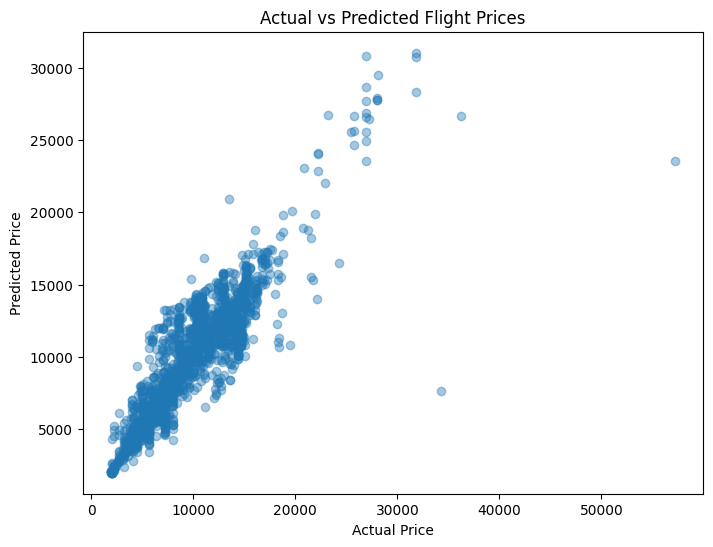

In [111]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.4)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Flight Prices")

plt.show()

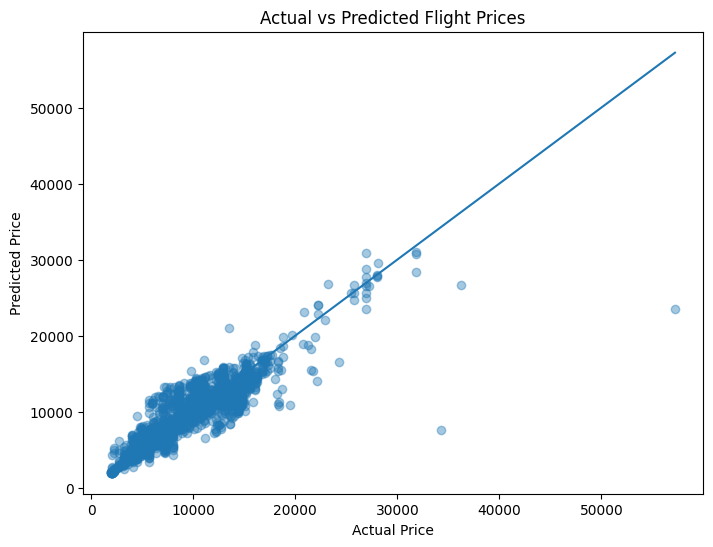

In [112]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.4)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Flight Prices")

plt.show()